# AG-HYPOPT · Trial 28

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-seven trials are registered; cell 2 reports `phase = trials` (27/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074). Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_21 (0.1074, best):** travel 0.138, balanced gamma (`lr_gamma=0.4716`, `gamma_anneal=0.4723`); 0 div.
- next best (all 0 div): trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138).
- plateau: trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127, trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (travel 0.194), trial_06 = trial_11 0.1188.
- diverging: trial_26 0.1368 (0.137, 1nW T05, a near-copy of trial_21), trial_17 0.1329 (0.088), trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: the mu-travel axis is now fully mapped - a single optimum spike at travel ~0.137-0.138, with worse results monotonically on both sides (low travel worse + occasional divergences; the large-travel probe trial_27 at 0.194 gave 0.1149). The key caveat is trial_26: a near-copy of trial_21 still diverged at 1nW T05, so the low-count gamma blow-up is unpredictable and trial_21's 0.1074 may be partly lucky; the typical divergence-free level is ~0.110-0.113. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_28'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (27/5 trials)
ID |     ei | params
 1 | 3.8490 | {"gamma_anneal": 0.49161656355839223, "lr_gamma": 0.464681927181863, "lr_mu": 0.16806044205966658, "mu_anneal": 0.3456301904184459}
 2 | 3.7534 | {"gamma_anneal": 0.5247945153487404, "lr_gamma": 0.4540540188329105, "lr_mu": 0.15128413670135898, "mu_anneal": 0.34722122202408773}
 3 | 3.5406 | {"gamma_anneal": 0.47765626266764427, "lr_gamma": 0.41514361421473445, "lr_mu": 0.1472787535093841, "mu_anneal": 0.3441937103988769}
 4 | 3.7123 | {"gamma_anneal": 0.6613417056088963, "lr_gamma": 0.4621236226717155, "lr_mu": 0.16753296568724424, "mu_anneal": 0.3464401497201952}
 5 | 1.9613 | {"gamma_anneal": 0.3046443978087033, "lr_gamma": 0.4757786605379836, "lr_mu": 0.15660229305769652, "mu_anneal": 0.34728619860120213}
 6 | 3.1770 | {"gamma_anneal": 0.44169824247983264, "lr_gamma": 0.4567842256374151, "lr_mu": 0.17812850813307765, "mu_anneal": 0.35455243139694875}
 7 | 0.9255 | {"gamma_anneal": 0.6195156613468928, "lr_gamma": 0.445

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (27 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 1: **ei 3.85** — `lr_mu=0.1681`, `mu_anneal=0.3456` (travel **0.139**), `lr_gamma=0.4647`, `gamma_anneal=0.4916`.
- candidate 2: ei 3.75 — `lr_mu=0.1513`, `mu_anneal=0.3472` (travel 0.125), `lr_gamma=0.4541`, `gamma_anneal=0.5248`.
- candidate 4: ei 3.71 — `lr_mu=0.1675`, `mu_anneal=0.3464` (travel 0.139), `lr_gamma=0.4621`, `gamma_anneal=0.6613`.
- candidate 3: ei 3.54 — `lr_mu=0.1473`, `mu_anneal=0.3442` (travel 0.122), `lr_gamma=0.4151`, `gamma_anneal=0.4777`.
- candidate 6: ei 3.18 — `lr_mu=0.1781`, `mu_anneal=0.3546` (travel 0.147), `lr_gamma=0.4568`.

Candidate 1 has the highest ei and sits on the optimum (travel 0.139, essentially trial_21's 0.138) with balanced gamma knobs (`lr_gamma=0.4647`, `gamma_anneal=0.4916`) matching the schedule that produced the best. Candidates 2 and 3 are near-optimum but with somewhat lower ei; candidate 4 is at the same travel but a high `gamma_anneal=0.661`; candidates 6/8 push to travel 0.147-0.151. Given the 1-D axis is mapped and the top-ei candidate is the best-point resample, candidate 1 is the natural pick - though, as trial_26 showed, an identical-looking point can still diverge at 1nW T05.

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.49161656355839223, 'lr_gamma': 0.464681927181863, 'lr_mu': 0.16806044205966658, 'mu_anneal': 0.3456301904184459}
Running  1nW Trans05 ... 

μ 9.39 -> 9.16 | γ 8.5 -> -49577353170026.96 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 47.10 | γ 8.5 -> 6.17 | NLL 5.49


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 78.12 | γ 14.1 -> 14.71 | NLL 3.73


Running 3nW Trans100 ... 

μ 175.71 -> 110.39 | γ 14.1 -> 14.24 | NLL 3.73



Total: 11.6 min


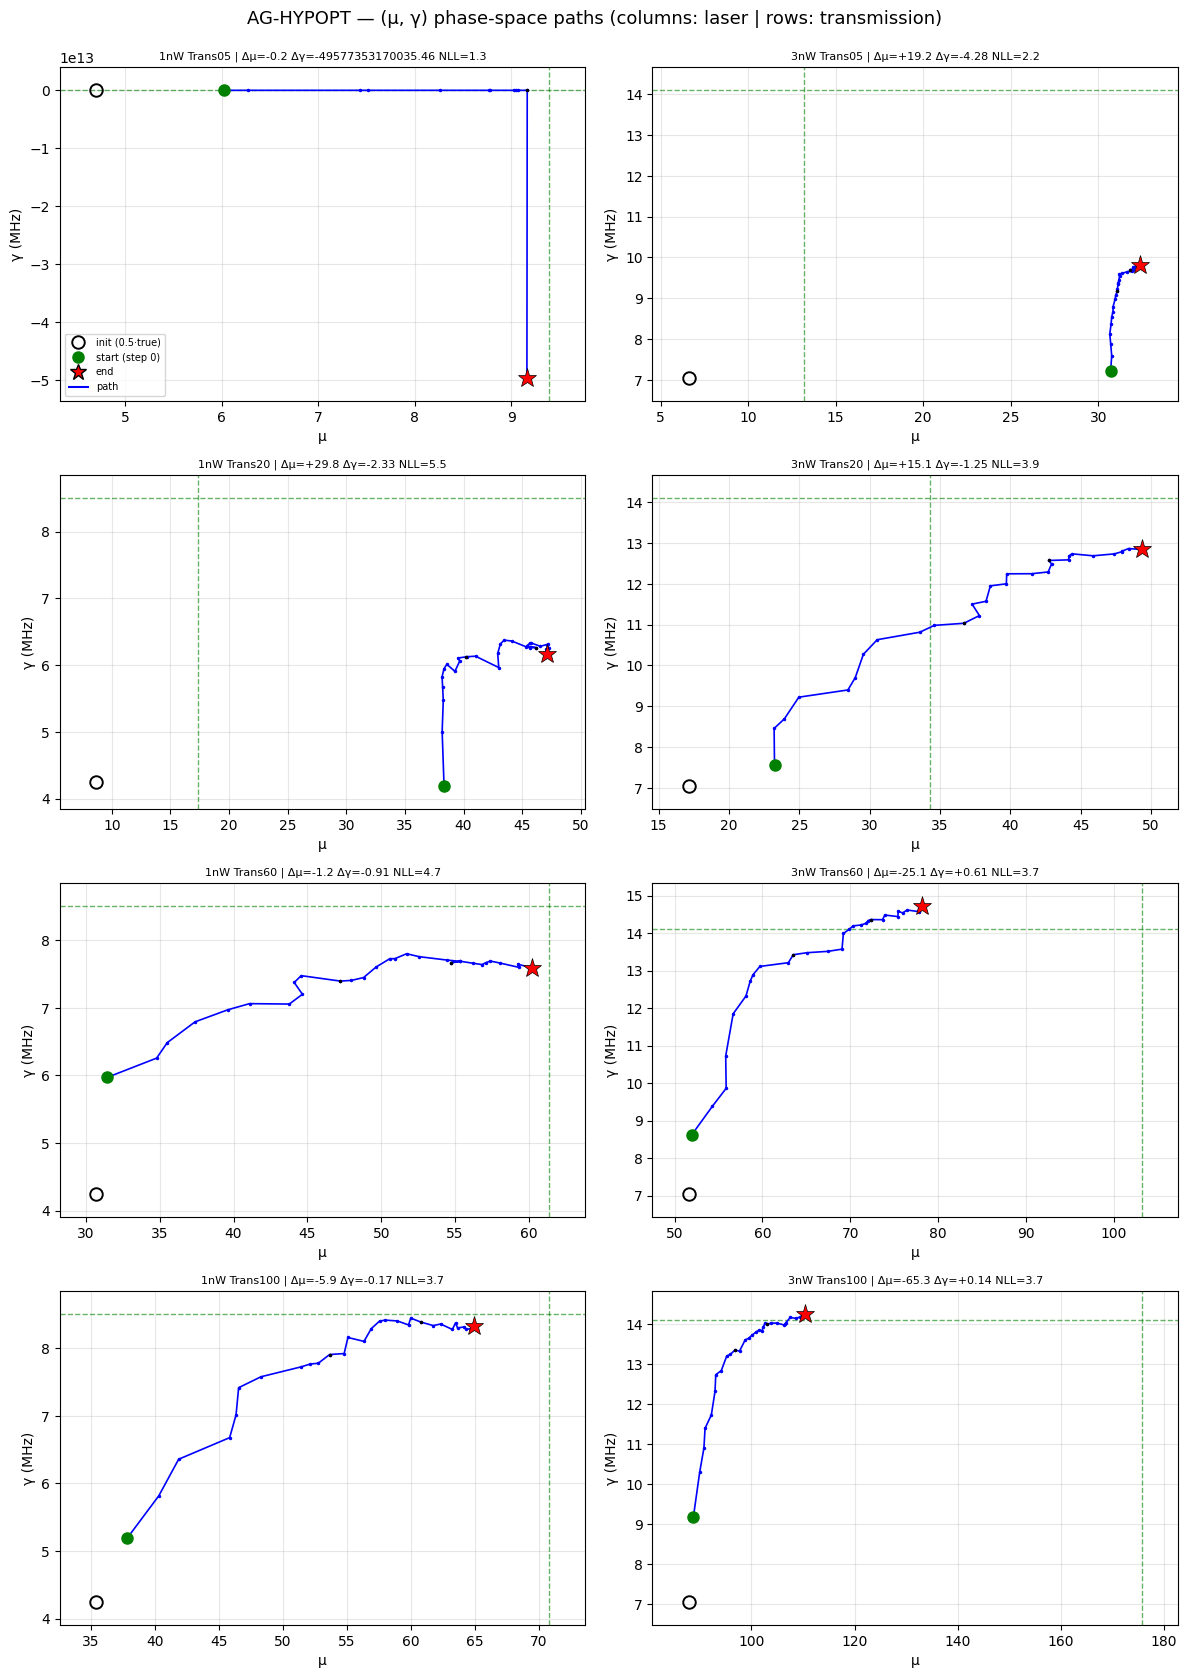

trial finished in 11.7 min
objective = 0.1370 ± 0.0973
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    9.16    -2.5 |     8.50-49577353170026.96-583262978471005.5
1nW Trans20       17.32   47.10  +172.0 |     8.50    6.17   -27.4
1nW Trans60       61.37   60.22    -1.9 |     8.50    7.59   -10.7
1nW Trans100       70.82   64.96    -8.3 |     8.50    8.33    -2.0
3nW Trans05       13.20   32.38  +145.3 |    14.10    9.82   -30.4
3nW Trans20       34.28   49.35   +44.0 |    14.10   12.85    -8.9
3nW Trans60      103.20   78.12   -24.3 |    14.10   14.71    +4.3
3nW Trans100      175.71  110.39   -37.2 |    14.10   14.24    +1.0

weighted objective (T-graded, cap=1.0) = 0.1370 | diverged cells: 1
μ: RMSE 28.314 (rel 82.7%, bias -4.202) | γ: RMSE 17528241309906.227 (rel 206214603645955.6%, bias -6197169146255.457)


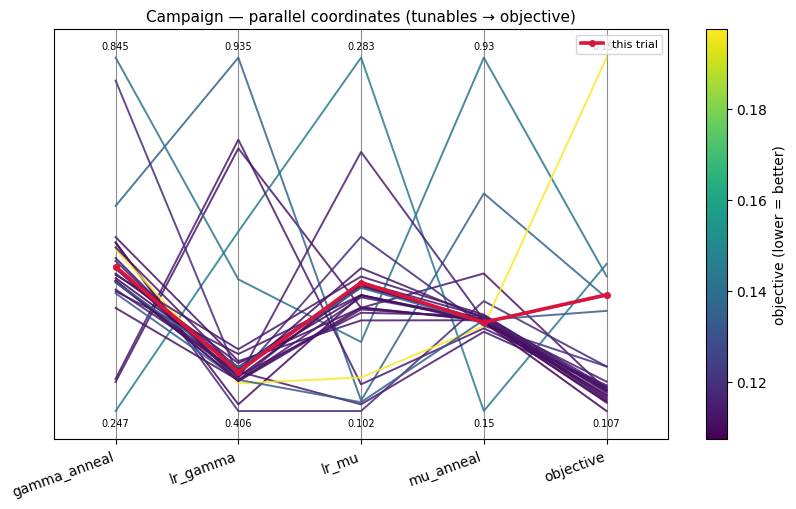

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 28 ran the highest-EI candidate (candidate 1, ei=3.85): `lr_mu=0.1681`, `mu_anneal=0.3456` (effective mu travel 0.139), `lr_gamma=0.4647`, `gamma_anneal=0.4916` — again essentially trial_21. It completed in 11.7 min with objective **0.1370 +/- 0.0973** and **1 diverged cell** (1nW T05: gamma -4.96e13). Ranking: trial_21 0.1074 < ... < **trial_28 0.1370** < ...

Aggregate accuracy: **mu rel-RMSE 82.7%** (RMSE 28.31, bias -4.20); gamma dominated by the diverged cell (raw RMSE 1.75e13).

Per-cell relative errors (1nW T05 gamma is the diverged value):
- **mu:** 1nW T05 -2.5%, T20 +172.0%, T60 -1.9%, T100 -8.3% | 3nW T05 +145.3%, T20 +44.0%, T60 -24.3%, T100 -37.2%.
- **gamma:** 1nW T05 **diverged (-4.96e13)**, T20 -27.4%, T60 -10.7%, T100 -2.0% | 3nW T05 -30.4%, T20 -8.9%, T60 +4.3%, T100 +1.0%.

This repeats the trial_26 lesson: a point on the optimum (travel 0.139, near-balanced gamma, essentially trial_21) diverged at 1nW T05, with the other seven cells behaving normally. The optimum-region runs now split **three survive (21, 22, 25) / three diverge (26, 28, plus 10 nearby at travel 0.099)** at the low-count cell — i.e. the divergence strikes roughly one in two-to-three attempts at essentially the same configuration. This strongly indicates that trial_21's 0.1074 is partly a lucky divergence-free draw and that the **typical** divergence-free performance of the optimum is ~0.110-0.113. trial_21 remains the recorded best by the registry's rule (it did complete with 0 divergences), but it should be read with this reproducibility caveat.

**Summary:** Trial 28 (lr_mu=0.1681, mu_anneal=0.3456, lr_gamma=0.4647, gamma_anneal=0.4916): objective 0.1370 +/- 0.0973 with 1 diverged cell (1nW T05, gamma -5.0e13); a third near-optimum run to blow up at 1nW T05, confirming the divergence is frequent and trial_21's 0.1074 is partly a lucky draw.
**Key insight:** The optimum travel (~0.138) diverges at 1nW T05 in roughly half of recent attempts (trials 26 and 28 diverged, 21/22/25 survived), so trial_21's divergence-free 0.1074 is not reliably reproducible and the honest expected performance is the typical ~0.110-0.113.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** With the divergence now clearly probabilistic at the optimum, the campaign's headline should be the typical divergence-free level (~0.110-0.113) rather than the single lucky 0.1074. Removing this hazard requires a structural fix (gradient clipping/damping or a divergence-aware guard on the low-count cell) that sits outside this campaign's hyperparameter scope. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 28 (lr_mu=0.1681, mu_anneal=0.3456, lr_gamma=0.4647, gamma_anneal=0.4916): objective 0.1370 +/- 0.0973 with 1 diverged cell (1nW T05, gamma -5.0e13); a third near-optimum run to blow up at 1nW T05, confirming the divergence is frequent and trial_21's 0.1074 is partly a lucky draw"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum travel (~0.138) diverges at 1nW T05 in roughly half of recent attempts (trials 26 and 28 diverged, 21/22/25 survived), so trial_21's divergence-free 0.1074 is not reliably reproducible and the honest expected performance is the typical ~0.110-0.113"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_28 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_29.ipynb. Open it and follow its cells from the top.
